# Batch Reactor — Prediksi Temperatur t+1 + Monitoring Anomali (Random Forest)

Notebook ini menjalankan seluruh alur secara berurutan dan **menyimpan semua hasil otomatis** ke folder `artifacts/`:

```
artifacts/
├── model/    -> reactor_temp_model.joblib + reactor_temp_model_metadata.json
├── tables/   -> ringkasan EDA, metrik evaluasi, threshold anomali, dll. (.csv)
├── images/   -> semua grafik (.png)
└── README.txt
```

**Alur:** (1) load + validasi 7 kolom → (2) EDA + cek konsistensi waktu per run → (3) preprocessing + target t+1 → (4) split per `Reactor_Run_ID` + latih Random Forest → (5) evaluasi + monitoring anomali → (6) export artefak.

Prinsip dari PRD: target = suhu aktual menit berikutnya (bukan rule 100°C), fitur = 5 kolom proses, split per run, status monitoring hanya *Normal pattern* / *Potential anomaly* (tanpa klaim defect atau Safe/Unsafe).

**Cara pakai:** jalankan semua sel (Runtime → Run all). Jika file CSV belum ada di folder kerja, Colab akan meminta Anda mengupload `reactor_sample_5k.csv`.

## 0. Import, Konfigurasi, dan Fungsi Pembantu
Semua pengaturan ada di sel ini. Ubah di sini saja, tidak perlu mengubah sel lain.

In [ ]:
import json
import math
import platform
import re
import shutil
import warnings
from datetime import datetime
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, GroupKFold, GroupShuffleSplit, cross_val_predict

warnings.filterwarnings('ignore', category=FutureWarning)

# ======================= KONFIGURASI =======================
CSV_FILENAME = 'reactor_sample_5k.csv'   # nama file dataset
OUTPUT_DIR = Path('artifacts')           # folder induk semua hasil

RANDOM_STATE = 42                        # agar hasil bisa diulang persis
TEST_SIZE = 0.25                         # porsi RUN (bukan baris) untuk data uji
CV_FOLDS = 5                             # jumlah fold GroupKFold (otomatis dikecilkan jika run sedikit)
MODEL_VERSION = 'rf-t1-v0.2'

# 7 kolom wajib sesuai PRD (Bagian 2.2 / 8.1)
TIME_COL = 'Timestamp_min'
TEMP_COL = 'Reactor_Temp_C'
RUN_COL = 'Reactor_Run_ID'
REQUIRED_COLUMNS = [TIME_COL, TEMP_COL, 'Jacket_Flow_Rate_L_min', 'Pressure_atm',
                    'Reactant_A_Conc_mol_L', 'Product_B_Conc_mol_L', RUN_COL]

# 5 fitur model (kondisi reaktor pada waktu t). Waktu dan Run ID sengaja TIDAK dipakai (PRD 9.2).
FEATURES = [TEMP_COL, 'Jacket_Flow_Rate_L_min', 'Pressure_atm',
            'Reactant_A_Conc_mol_L', 'Product_B_Conc_mol_L']
TARGET_COL = 'Temp_next'                 # nama kolom target = Reactor_Temp_C pada t+1

# Kandidat hyperparameter Random Forest (dicari dengan GroupKFold di data train saja)
PARAM_GRID = {'max_depth': [None, 12], 'min_samples_leaf': [1, 3, 5], 'max_features': [1.0, 0.6]}
N_ESTIMATORS = 200

# Opsi threshold anomali dari distribusi error out-of-fold
THRESHOLD_PERCENTILES = [90, 95, 99]     # persentil error
THRESHOLD_STD_K = [2, 3]                 # mean + k * std
PROVISIONAL_THRESHOLD = 'p95'            # HANYA nilai demo sementara; keputusan final ada di tim

# ======================= FOLDER OUTPUT =======================
MODEL_DIR = OUTPUT_DIR / 'model'
TABLE_DIR = OUTPUT_DIR / 'tables'
IMAGE_DIR = OUTPUT_DIR / 'images'
for folder in (MODEL_DIR, TABLE_DIR, IMAGE_DIR):
    folder.mkdir(parents=True, exist_ok=True)   # exist_ok -> aman dijalankan berulang

SAVED_FILES = []                         # daftar semua file yang disimpan (untuk README)
plt.rcParams['figure.figsize'] = (10, 4)


# ======================= FUNGSI PEMBANTU =======================
def save_table(df, name, index=True):
    # Simpan DataFrame ke artifacts/tables/<name>.csv (utf-8-sig agar terbuka rapi di Excel)
    path = TABLE_DIR / (name + '.csv')
    df.to_csv(path, index=index, encoding='utf-8-sig')
    SAVED_FILES.append(path)
    return path


def save_fig(name):
    # Simpan grafik aktif ke artifacts/images/<name>.png, tampilkan, lalu tutup figure
    path = IMAGE_DIR / (name + '.png')
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches='tight')
    SAVED_FILES.append(path)
    plt.show()
    plt.close()
    return path


def regression_metrics(y_true, y_pred):
    # Tiga metrik regresi PRD 9.7. Nama kunci ASCII agar aman di CSV/JSON.
    return {'MAE_C': float(mean_absolute_error(y_true, y_pred)),
            'RMSE_C': float(np.sqrt(mean_squared_error(y_true, y_pred))),
            'R2': float(r2_score(y_true, y_pred))}


def to_jsonable(obj):
    # Ubah tipe numpy/pandas/Path menjadi tipe biasa agar bisa ditulis ke JSON tanpa error
    if isinstance(obj, dict):
        return {str(k): to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple, set)):
        return [to_jsonable(v) for v in obj]
    if isinstance(obj, np.generic):
        return obj.item()
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (pd.Series, pd.Index)):
        return obj.tolist()
    if isinstance(obj, Path):
        return str(obj)
    return obj


print('Folder output:', OUTPUT_DIR.resolve())

Folder output: /content/artifacts


## 1. Load Dataset & Validasi 7 Kolom Wajib (PRD 9.4 langkah 1–3)

Fungsi `load_and_validate` melakukan pemeriksaan berikut dan memberi **pesan error yang jelas** (bukan error acak):
1. File ada (atau meminta upload di Colab).
2. Spasi/huruf besar-kecil pada nama kolom dirapikan otomatis.
3. Header rusak (semua kolom bernama sama) dikenali dan dijelaskan.
4. Kolom wajib yang hilang dilaporkan satu per satu.
5. Kolom tambahan diabaikan (PRD 8.3: tidak dipakai sebelum didiskusikan).
6. Nilai non-numerik pada kolom numerik diubah menjadi kosong (NaN) dan dihitung jumlahnya.

In [ ]:
def locate_csv(filename):
    # Cari file di folder kerja; jika tidak ada dan sedang di Colab, minta upload.
    path = Path(filename)
    if path.exists():
        return path
    try:
        from google.colab import files          # hanya ada di Google Colab
        print('File belum ada. Silakan upload', filename)
        uploaded = files.upload()
        if not uploaded:
            raise FileNotFoundError('Tidak ada file yang diupload.')
        return Path(list(uploaded.keys())[0])
    except ImportError:
        raise FileNotFoundError(
            'File ' + filename + ' tidak ditemukan di folder kerja: ' + str(Path.cwd()))


def load_and_validate(path, required):
    # Baca CSV lalu pastikan 7 kolom wajib tersedia dan bertipe benar. Mengembalikan DataFrame bersih.
    df = pd.read_csv(path)
    df.columns = [str(c).strip() for c in df.columns]          # buang spasi di nama kolom

    # Samakan huruf besar/kecil: 'reactor_temp_c' -> 'Reactor_Temp_C'
    lower_to_required = {c.lower(): c for c in required}
    df = df.rename(columns={c: lower_to_required[c.lower()]
                            for c in df.columns if c.lower() in lower_to_required})

    missing = [c for c in required if c not in df.columns]
    if missing:
        # pandas mengubah nama kembar menjadi 'nama.1', 'nama.2', ... -> tanda header rusak
        mangled = [c for c in df.columns if re.search(r'\.\d+$', c)]
        hint = ''
        if mangled:
            hint = ('\nPetunjuk: nama kolom berulang/bernomor (' + ', '.join(df.columns[:4]) +
                    ', ...) menandakan header CSV rusak. Gunakan file CSV dengan header yang benar.')
        raise ValueError('Kolom wajib tidak ditemukan: ' + str(missing) +
                         '\nKolom di file: ' + str(list(df.columns)) + hint)

    extra = [c for c in df.columns if c not in required]
    if extra:
        print('Peringatan: kolom tambahan diabaikan ->', extra)
    df = df[required].copy()

    # Kolom numerik: ubah teks yang tidak valid menjadi NaN (jumlahnya dilaporkan)
    numeric_cols = [c for c in required if c != RUN_COL]
    for c in numeric_cols:
        before_na = df[c].isna().sum()
        df[c] = pd.to_numeric(df[c], errors='coerce')
        coerced = int(df[c].isna().sum() - before_na)
        if coerced > 0:
            print('Peringatan: ' + str(coerced) + ' nilai non-numerik di kolom ' + c + ' diubah menjadi NaN')
    return df


csv_path = locate_csv(CSV_FILENAME)
df = load_and_validate(csv_path, REQUIRED_COLUMNS)
print('File   :', csv_path)
print('Bentuk :', df.shape, '| 7 kolom wajib tervalidasi')
display(df.head())

File   : reactor_sample_5k.csv
Bentuk : (4901, 7) | 7 kolom wajib tervalidasi


,Timestamp_min,Reactor_Temp_C,Jacket_Flow_Rate_L_min,Pressure_atm,Reactant_A_Conc_mol_L,Product_B_Conc_mol_L,Reactor_Run_ID
0,0,85.0,1015,3.20,2.50,0.00,1
1,1,84.5,1007,3.18,2.49,0.01,1
2,2,85.0,1012,3.22,2.48,0.02,1
3,3,85.5,1019,3.16,2.47,0.03,1
4,4,84.0,1002,3.21,2.46,0.04,1


## 2. EDA & Pengecekan Konsistensi Waktu per `Reactor_Run_ID` (Milestone 1)

Tabel ringkasan ini sama dengan tabel PRD 8.2 dan **disimpan otomatis ke `artifacts/tables/`**.
Interval waktu yang “normal” dideteksi otomatis (nilai interval yang paling sering muncul), bukan diasumsikan 1 menit.

In [ ]:
# Urutkan agar selisih waktu dihitung benar: per run, naik menurut waktu
df_sorted = df.sort_values([RUN_COL, TIME_COL]).reset_index(drop=True)
by_run = df_sorted.groupby(RUN_COL)

step = by_run[TIME_COL].diff()                       # selisih waktu antar baris dalam run yang sama
valid_steps = step.dropna()
EXPECTED_STEP = float(valid_steps[valid_steps > 0].mode().iloc[0]) if (valid_steps > 0).any() else 1.0

n_duplicate_rows = int(df.duplicated().sum())
n_duplicate_time = int(df_sorted.duplicated([RUN_COL, TIME_COL]).sum())
n_backward = int((valid_steps < 0).sum())            # setelah sort seharusnya 0
n_gap = int((valid_steps > EXPECTED_STEP).sum())     # lompatan waktu lebih besar dari interval normal
run_lengths = by_run.size()

eda_summary = pd.DataFrame([
    ('Jumlah baris total', len(df)),
    ('Jumlah Reactor_Run_ID unik', df[RUN_COL].nunique()),
    ('Panjang run min / maks / rata-rata',
     str(run_lengths.min()) + ' / ' + str(run_lengths.max()) + ' / ' + str(round(run_lengths.mean(), 1))),
    ('Interval waktu normal (menit)', EXPECTED_STEP),
    ('Interval seragam di semua run?', bool((valid_steps == EXPECTED_STEP).all())),
    ('Jumlah lompatan waktu dalam run', n_gap),
    ('Jumlah timestamp ganda dalam run', n_duplicate_time),
    ('Jumlah baris duplikat penuh', n_duplicate_rows),
    ('Total missing value (7 kolom)', int(df.isna().sum().sum())),
], columns=['Item', 'Hasil']).set_index('Item')
display(eda_summary)

desc_stats = df.describe().T
missing_by_col = df.isna().sum().to_frame('jumlah_missing')

# Ringkasan per run + deteksi lompatan waktu (untuk konsistensi waktu per run)
run_summary = by_run.agg(n_baris=(TIME_COL, 'size'), waktu_awal=(TIME_COL, 'min'), waktu_akhir=(TIME_COL, 'max'),
                         suhu_min=(TEMP_COL, 'min'), suhu_maks=(TEMP_COL, 'max'), suhu_rata2=(TEMP_COL, 'mean'))
run_summary['n_lompatan_waktu'] = (step > EXPECTED_STEP).groupby(df_sorted[RUN_COL]).sum().astype(int)
time_gaps = df_sorted.assign(selisih_ke_baris_berikutnya=by_run[TIME_COL].shift(-1) - df_sorted[TIME_COL])
time_gaps = time_gaps[time_gaps['selisih_ke_baris_berikutnya'] > EXPECTED_STEP][[RUN_COL, TIME_COL, 'selisih_ke_baris_berikutnya']]

print('Lompatan waktu di dalam run:')
display(time_gaps if len(time_gaps) else 'tidak ada')
display(desc_stats.round(3))

save_table(eda_summary, 'eda_summary')
save_table(desc_stats.round(4), 'eda_descriptive_stats')
save_table(missing_by_col, 'eda_missing_by_column')
save_table(run_summary.round(3), 'eda_run_summary')
save_table(time_gaps, 'eda_time_gaps', index=False)

,Hasil
Item,
Jumlah baris total,4901
Jumlah Reactor_Run_ID unik,27
Panjang run min / maks / rata-rata,100 / 290 / 181.5
Interval waktu normal (menit),1.0
Interval seragam di semua run?,False
Jumlah lompatan waktu dalam run,1
Jumlah timestamp ganda dalam run,0
Jumlah baris duplikat penuh,0
Total missing value (7 kolom),0


Lompatan waktu di dalam run:


,Reactor_Run_ID,Timestamp_min,selisih_ke_baris_berikutnya
2957,17,2957,101.0


,count,mean,std,min,25%,50%,75%,max
Timestamp_min,4901.0,2489.645,1456.621,0.00,1225.00,2450.0,3775.00,5000.00
Reactor_Temp_C,4901.0,88.206,7.898,60.50,84.85,85.1,90.00,110.00
Jacket_Flow_Rate_L_min,4901.0,1012.612,8.740,936.00,1010.00,1014.0,1016.00,1063.00
Pressure_atm,4901.0,3.193,0.157,2.22,3.17,3.2,3.22,4.49
Reactant_A_Conc_mol_L,4901.0,1.401,0.779,0.00,0.72,1.6,2.06,2.50
Product_B_Conc_mol_L,4901.0,1.098,0.778,0.00,0.44,0.9,1.77,2.50
Reactor_Run_ID,4901.0,14.552,7.580,1.00,8.00,15.0,21.00,27.00


PosixPath('artifacts/tables/eda_time_gaps.csv')

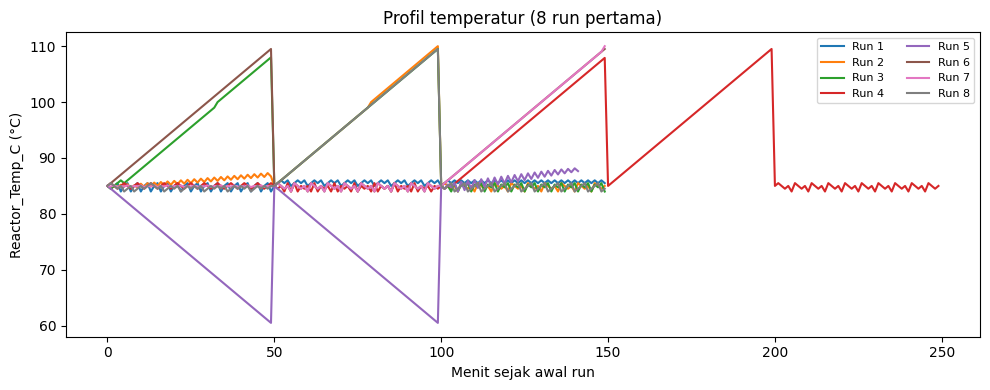

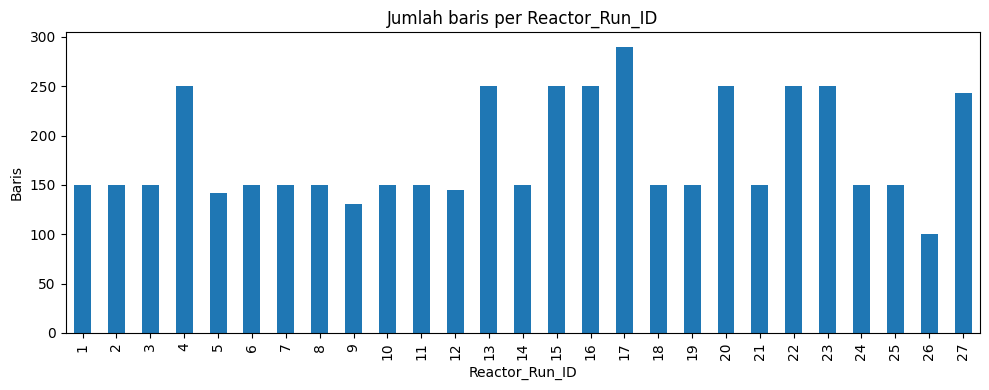

PosixPath('artifacts/images/02_panjang_run.png')

In [ ]:
# Grafik 1: profil suhu beberapa run (suhu = time series, bukan nilai akhir)
fig, ax = plt.subplots()
for rid in df_sorted[RUN_COL].unique()[:8]:
    d = df_sorted[df_sorted[RUN_COL] == rid]
    ax.plot(d[TIME_COL] - d[TIME_COL].min(), d[TEMP_COL], label='Run ' + str(rid))
ax.set_title('Profil temperatur (8 run pertama)')
ax.set_xlabel('Menit sejak awal run'); ax.set_ylabel('Reactor_Temp_C (°C)'); ax.legend(ncol=2, fontsize=8)
save_fig('01_profil_suhu_per_run')

# Grafik 2: panjang tiap run
fig, ax = plt.subplots()
run_lengths.plot.bar(ax=ax)
ax.set_title('Jumlah baris per Reactor_Run_ID'); ax.set_xlabel('Reactor_Run_ID'); ax.set_ylabel('Baris')
save_fig('02_panjang_run')

## 3. Preprocessing & Target t+1 di Dalam Masing-masing Run (PRD 9.3–9.4)

Urutan: sort → buang baris dengan missing/duplikat waktu → target `t+1` dibuat **per run** → buang baris yang tidak punya `t+1` yang sah.

- Baris terakhir tiap run dibuang (tidak diisi nilai buatan).
- Pasangan (t, t+1) hanya dipakai bila selisih waktunya tepat satu interval normal. Pasangan yang melompati waktu dibuang.
- Tidak ada scaling/imputasi statistik, sehingga tidak ada kebocoran dari preprocessing.

In [ ]:
data = df.sort_values([RUN_COL, TIME_COL]).reset_index(drop=True)

# Langkah 1: buang baris dengan nilai kosong (strategi sementara: drop, bukan imputasi)
n_start = len(data)
data = data.dropna(subset=REQUIRED_COLUMNS)
n_dropped_missing = n_start - len(data)

# Langkah 2: buang timestamp ganda dalam satu run (jaga urutan waktu unik)
n_before = len(data)
data = data.drop_duplicates(subset=[RUN_COL, TIME_COL], keep='first').reset_index(drop=True)
n_dropped_dup = n_before - len(data)

# Langkah 3: target t+1 = suhu pada baris berikutnya DI DALAM run yang sama (shift per grup)
by_run = data.groupby(RUN_COL)
data[TARGET_COL] = by_run[TEMP_COL].shift(-1)
data['_selisih_waktu'] = by_run[TIME_COL].shift(-1) - data[TIME_COL]

# Langkah 4: pilih hanya pasangan sah (ada t+1 dan selisih waktu = interval normal)
has_target = data[TARGET_COL].notna()
n_last_rows = int((~has_target).sum())                                    # baris terakhir tiap run
n_time_jump = int((has_target & (data['_selisih_waktu'] != EXPECTED_STEP)).sum())
model_df = data[has_target & (data['_selisih_waktu'] == EXPECTED_STEP)].copy()

if len(model_df) == 0:
    raise ValueError('Tidak ada sampel (X, y) yang valid setelah preprocessing. Periksa data.')

X = model_df[FEATURES]
y = model_df[TARGET_COL]
groups = model_df[RUN_COL]

prep_report = pd.DataFrame([
    ('Baris awal', n_start),
    ('Dibuang: missing value', n_dropped_missing),
    ('Dibuang: timestamp ganda', n_dropped_dup),
    ('Dibuang: baris terakhir tiap run (tanpa t+1)', n_last_rows),
    ('Dibuang: pasangan melompati waktu', n_time_jump),
    ('Sampel (X, y) siap pakai', len(model_df)),
], columns=['Tahap', 'Jumlah']).set_index('Tahap')
display(prep_report)
save_table(prep_report, 'preprocessing_report')

,Jumlah
Tahap,
Baris awal,4901
Dibuang: missing value,0
Dibuang: timestamp ganda,0
Dibuang: baris terakhir tiap run (tanpa t+1),27
Dibuang: pasangan melompati waktu,1
"Sampel (X, y) siap pakai",4873


PosixPath('artifacts/tables/preprocessing_report.csv')

In [ ]:
# Pemeriksaan data leakage. Jika ada pelanggaran, notebook berhenti dengan pesan jelas.
checks = []

# (a) Target tidak boleh ada di fitur; fitur hanya dari baris t
assert TARGET_COL not in FEATURES, 'Target bocor ke fitur'
checks.append(('Target leakage', 'OK', 'X hanya berisi 5 kolom pada baris t'))

# (b) Verifikasi ulang target: cari suhu pada (run yang sama, waktu t + interval) dan bandingkan
lookup = data.set_index([RUN_COL, TIME_COL])[TEMP_COL]
keys = list(zip(model_df[RUN_COL], model_df[TIME_COL] + EXPECTED_STEP))
expected_y = lookup.reindex(pd.MultiIndex.from_tuples(keys, names=[RUN_COL, TIME_COL])).values
assert np.allclose(expected_y, model_df[TARGET_COL].values), 'Target t+1 tidak cocok (lintas run?)'
checks.append(('Cross-run leakage', 'OK', 'Target diverifikasi ulang: run sama, waktu t+1'))

checks.append(('Future-information leakage', 'OK', 'Tidak ada fitur turunan (rolling/lag)'))
checks.append(('Preprocessing leakage', 'OK', 'Tidak ada scaling/imputasi berbasis statistik'))

## 4. Split per `Reactor_Run_ID` & Pelatihan Random Forest (PRD 9.5–9.6)

- **Split:** seluruh baris satu run masuk ke train **atau** test, tidak pernah keduanya (`GroupShuffleSplit`). Ini mengukur kemampuan model pada run yang belum pernah dilihat.
- **Tuning:** `GridSearchCV` dengan `GroupKFold` di data train saja. Data test tidak disentuh sampai evaluasi.
- Jumlah fold otomatis dikecilkan bila jumlah run training sedikit.

In [ ]:
n_runs = groups.nunique()
if n_runs < 3:
    raise ValueError('Butuh minimal 3 Reactor_Run_ID untuk split per run, ditemukan ' + str(n_runs))

splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
g_train, g_test = groups.iloc[train_idx], groups.iloc[test_idx]

# Pemeriksaan split leakage: tidak boleh ada run yang sama di train dan test
assert set(g_train).isdisjoint(set(g_test)), 'Ada Reactor_Run_ID di train dan test sekaligus'
checks.append(('Split leakage', 'OK', 'Tidak ada Reactor_Run_ID di train dan test sekaligus'))

leakage_table = pd.DataFrame(checks, columns=['Jenis', 'Status', 'Keterangan']).set_index('Jenis')
display(leakage_table)
save_table(leakage_table, 'leakage_checks')

split_info = pd.DataFrame({
    'Item': ['Metode', 'Run train', 'Run test', 'Sampel train', 'Sampel test'],
    'Isi': ['GroupShuffleSplit per Reactor_Run_ID (random_state=' + str(RANDOM_STATE) + ')',
            str(g_train.nunique()) + ' run', str(g_test.nunique()) + ' run: ' + str(sorted(g_test.unique().tolist())),
            len(X_train), len(X_test)]}).set_index('Item')
display(split_info)
save_table(split_info, 'split_info')

# Jumlah fold tidak boleh melebihi jumlah run di train
n_splits_train = min(CV_FOLDS, g_train.nunique())
if n_splits_train < 2:
    raise ValueError('Run training terlalu sedikit untuk GroupKFold.')

,Status,Keterangan
Jenis,,
Target leakage,OK,X hanya berisi 5 kolom pada baris t
Cross-run leakage,OK,"Target diverifikasi ulang: run sama, waktu t+1"
Future-information leakage,OK,Tidak ada fitur turunan (rolling/lag)
Preprocessing leakage,OK,Tidak ada scaling/imputasi berbasis statistik
Split leakage,OK,Tidak ada Reactor_Run_ID di train dan test sek...


,Isi
Item,
Metode,GroupShuffleSplit per Reactor_Run_ID (random_s...
Run train,20 run
Run test,"7 run: [1, 9, 10, 12, 14, 17, 22]"
Sampel train,3615
Sampel test,1258


In [ ]:
# Cari hyperparameter terbaik; fold dipisah per run sehingga tuning juga bebas leakage
search = GridSearchCV(
    RandomForestRegressor(n_estimators=N_ESTIMATORS, random_state=RANDOM_STATE, n_jobs=-1),
    PARAM_GRID, cv=GroupKFold(n_splits=n_splits_train),
    scoring='neg_mean_absolute_error', n_jobs=1)
search.fit(X_train, y_train, groups=g_train)

BEST_PARAMS = dict(search.best_params_)
BEST_PARAMS.update({'n_estimators': N_ESTIMATORS, 'random_state': RANDOM_STATE})
print('Hyperparameter terpilih:', BEST_PARAMS)
print('MAE CV (leave-runs-out, data train): ' + str(round(-search.best_score_, 4)) + ' °C')

grid_results = pd.DataFrame(search.cv_results_)[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
grid_results['mean_MAE_C'] = -grid_results['mean_test_score']
save_table(grid_results.drop(columns=['mean_test_score']).sort_values('rank_test_score'), 'grid_search_results', index=False)

# Latih model evaluasi pada data train
model = RandomForestRegressor(**BEST_PARAMS, n_jobs=-1).fit(X_train, y_train)

Hyperparameter terpilih: {'max_depth': 12, 'max_features': 1.0, 'min_samples_leaf': 5, 'n_estimators': 200, 'random_state': 42}
MAE CV (leave-runs-out, data train): 0.3572 °C


## 5a. Evaluasi: MAE, RMSE, R² (PRD 9.7)

Model dibandingkan dengan **baseline naif** (“suhu berikutnya = suhu sekarang”) agar angka punya konteks. Karena jumlah run terbatas, ditambahkan juga *leave-runs-out cross-validation* pada seluruh run untuk melihat kestabilan hasil.

In [ ]:
pred_test = model.predict(X_test)
naive_test = X_test[TEMP_COL].values                      # baseline: T(t+1) = T(t)

eval_table = pd.DataFrame({'Random Forest': regression_metrics(y_test, pred_test),
                           'Baseline naif': regression_metrics(y_test, naive_test)}).T
eval_table['Perbaikan_MAE_persen'] = [100 * (1 - eval_table.loc['Random Forest', 'MAE_C'] / eval_table.loc['Baseline naif', 'MAE_C']), np.nan]
print('Evaluasi pada data TEST (run yang tidak dipakai training):')
display(eval_table.round(4))
save_table(eval_table.round(5), 'evaluation_metrics')

# Cross-validation per run pada seluruh data (stabilitas hasil)
n_splits_all = min(CV_FOLDS, n_runs)
oof_all = cross_val_predict(RandomForestRegressor(**BEST_PARAMS, n_jobs=-1), X, y,
                            cv=GroupKFold(n_splits=n_splits_all), groups=groups)
fold_rows = []
for k, (_, val_idx) in enumerate(GroupKFold(n_splits=n_splits_all).split(X, y, groups=groups), start=1):
    m = regression_metrics(y.iloc[val_idx], oof_all[val_idx])
    m_naive = regression_metrics(y.iloc[val_idx], X.iloc[val_idx][TEMP_COL])
    fold_rows.append({'fold': k, 'n_run_validasi': groups.iloc[val_idx].nunique(), 'MAE_RF_C': m['MAE_C'],
                      'RMSE_RF_C': m['RMSE_C'], 'R2_RF': m['R2'], 'MAE_naif_C': m_naive['MAE_C']})
cv_table = pd.DataFrame(fold_rows).set_index('fold')
display(cv_table.round(4))
print('MAE RF antar-fold: ' + str(round(cv_table['MAE_RF_C'].mean(), 3)) + ' ± ' + str(round(cv_table['MAE_RF_C'].std(), 3)) + ' °C')
save_table(cv_table.round(5), 'cv_fold_metrics')

# Simpan prediksi data test (aktual, prediksi, error) untuk analisis lanjutan
test_predictions = model_df.iloc[test_idx][[RUN_COL, TIME_COL] + FEATURES].copy()
test_predictions['Actual_next_temp'] = y_test.values
test_predictions['Predicted_next_temp'] = pred_test
test_predictions['Abs_error'] = np.abs(y_test.values - pred_test)
save_table(test_predictions.round(4), 'test_predictions', index=False)

Evaluasi pada data TEST (run yang tidak dipakai training):


,MAE_C,RMSE_C,R2,Perbaikan_MAE_persen
Random Forest,0.4937,0.7844,0.987,31.9464
Baseline naif,0.7255,1.7266,0.937,NaN


,n_run_validasi,MAE_RF_C,RMSE_RF_C,R2_RF,MAE_naif_C
fold,,,,,
1,6,0.2657,0.9009,0.9893,0.6352
2,5,0.2414,0.8767,0.9855,0.6050
3,5,0.3560,0.9252,0.9853,0.7676
4,6,0.5778,1.3979,0.9655,0.7938
5,5,0.3346,0.9617,0.9815,0.6749


MAE RF antar-fold: 0.355 ± 0.133 °C


PosixPath('artifacts/tables/test_predictions.csv')

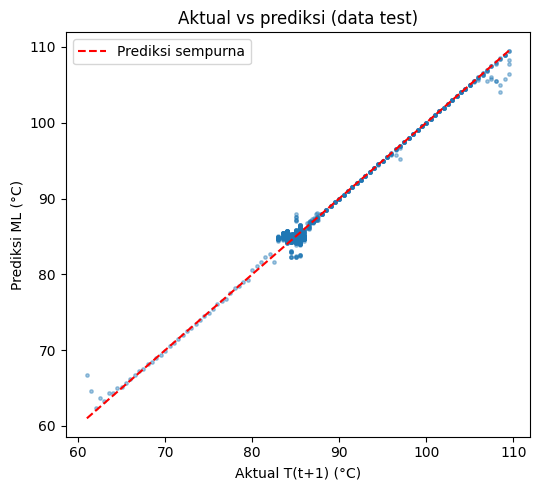

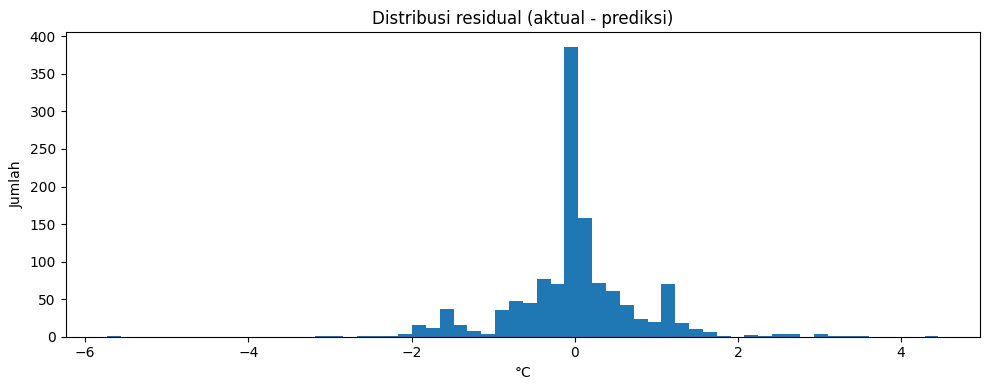

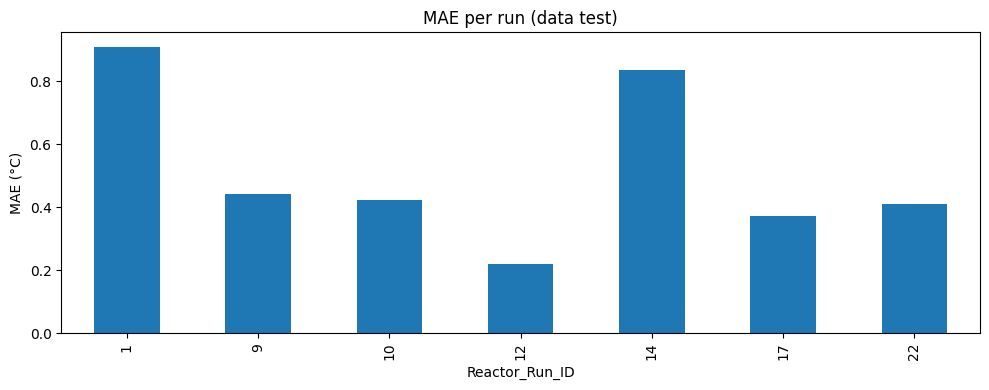

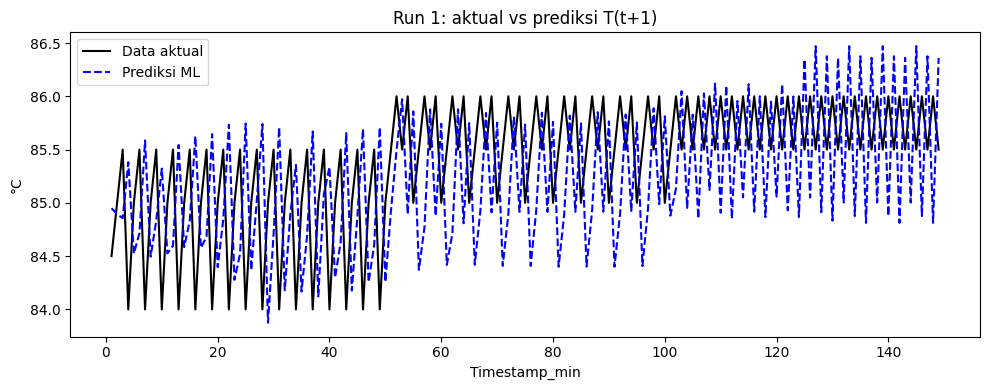

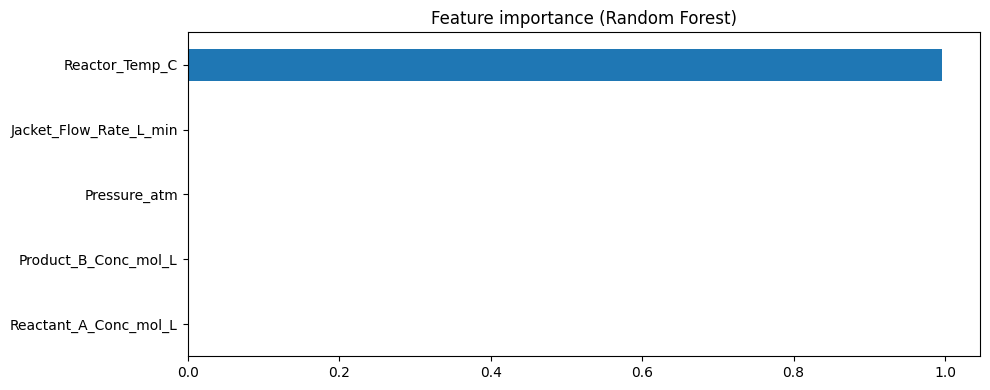

PosixPath('artifacts/tables/feature_importance.csv')

In [ ]:
# Grafik 3: aktual vs prediksi (data test)
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(y_test, pred_test, s=6, alpha=0.4)
lo, hi = float(min(y_test.min(), pred_test.min())), float(max(y_test.max(), pred_test.max()))
ax.plot([lo, hi], [lo, hi], 'r--', label='Prediksi sempurna')
ax.set_xlabel('Aktual T(t+1) (°C)'); ax.set_ylabel('Prediksi ML (°C)'); ax.set_title('Aktual vs prediksi (data test)'); ax.legend()
save_fig('03_aktual_vs_prediksi')

# Grafik 4: distribusi residual (aktual - prediksi)
residual = y_test.values - pred_test
fig, ax = plt.subplots()
ax.hist(residual, bins=60)
ax.set_title('Distribusi residual (aktual - prediksi)'); ax.set_xlabel('°C'); ax.set_ylabel('Jumlah')
save_fig('04_distribusi_residual')

# Grafik 5: MAE per run pada data test
mae_per_run = test_predictions.groupby(RUN_COL)['Abs_error'].mean()
fig, ax = plt.subplots()
mae_per_run.plot.bar(ax=ax)
ax.set_title('MAE per run (data test)'); ax.set_xlabel('Reactor_Run_ID'); ax.set_ylabel('MAE (°C)')
save_fig('05_mae_per_run_test')
save_table(mae_per_run.round(4).to_frame('MAE_C'), 'mae_per_run_test')

# Grafik 6: satu run test, aktual (garis solid) vs prediksi ML (putus-putus)
demo_run = sorted(g_test.unique())[0]
d = test_predictions[test_predictions[RUN_COL] == demo_run].sort_values(TIME_COL)
fig, ax = plt.subplots()
ax.plot(d[TIME_COL] + EXPECTED_STEP, d['Actual_next_temp'], 'k-', label='Data aktual')
ax.plot(d[TIME_COL] + EXPECTED_STEP, d['Predicted_next_temp'], 'b--', label='Prediksi ML')
ax.set_title('Run ' + str(demo_run) + ': aktual vs prediksi T(t+1)'); ax.set_xlabel(TIME_COL); ax.set_ylabel('°C'); ax.legend()
save_fig('06_deret_waktu_run_test')

# Grafik 7 + tabel: feature importance (hanya indikasi pola prediksi, bukan bukti sebab-akibat)
importance = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
fig, ax = plt.subplots()
importance.plot.barh(ax=ax, title='Feature importance (Random Forest)')
save_fig('07_feature_importance')
save_table(importance.sort_values(ascending=False).to_frame('importance'), 'feature_importance')

## 5b. Monitoring Anomali Berbasis Prediction Error (PRD Bagian 10)

```
Prediction Error = | Aktual(t+1) − Prediksi(t+1) |
```
Error besar berarti **menyimpang dari pola yang dipelajari model**. Itu **bukan** otomatis defect, kerusakan, atau kondisi tidak aman, dan threshold ini **bukan batas keselamatan**.

Threshold diturunkan dari **error out-of-fold** (prediksi untuk run yang tidak ikut melatih model), bukan error training. Error training Random Forest hampir selalu terlalu kecil sehingga threshold-nya jadi terlalu ketat.

In [ ]:
# Error out-of-fold pada data train (tiap run diprediksi oleh model yang tidak melihat run itu)
oof_train = cross_val_predict(RandomForestRegressor(**BEST_PARAMS, n_jobs=-1), X_train, y_train,
                              cv=GroupKFold(n_splits=n_splits_train), groups=g_train)
err_oof_train = np.abs(y_train.values - oof_train)
err_test = np.abs(y_test.values - pred_test)

# Distribusi error (statistik + persentil)
quantiles = [0.5, 0.75, 0.9, 0.95, 0.99]
error_dist = pd.DataFrame({'Error_OOF_train': pd.Series(err_oof_train).describe(percentiles=quantiles),
                           'Error_test': pd.Series(err_test).describe(percentiles=quantiles)})
display(error_dist.round(3))
save_table(error_dist.round(4), 'error_distribution')

# Opsi threshold: persentil dan mean + k*std dari error OOF train
def build_threshold_options(errors):
    options = {}
    for p in THRESHOLD_PERCENTILES:
        options['p' + str(p)] = float(np.percentile(errors, p))
    for k in THRESHOLD_STD_K:
        options['mean_plus_' + str(k) + 'std'] = float(errors.mean() + k * errors.std())
    return options

threshold_options_train = build_threshold_options(err_oof_train)
threshold_table = pd.DataFrame({
    'Threshold_C': threshold_options_train,
    'Persen_OOF_train_ditandai': {k: float((err_oof_train > v).mean() * 100) for k, v in threshold_options_train.items()},
    'Persen_test_ditandai': {k: float((err_test > v).mean() * 100) for k, v in threshold_options_train.items()},
})
display(threshold_table.round(3))
save_table(threshold_table.round(4), 'threshold_options')

if PROVISIONAL_THRESHOLD not in threshold_options_train:
    raise KeyError('PROVISIONAL_THRESHOLD harus salah satu dari: ' + str(list(threshold_options_train)))
demo_threshold = threshold_options_train[PROVISIONAL_THRESHOLD]
print('Threshold demo sementara (' + PROVISIONAL_THRESHOLD + '): ' + str(round(demo_threshold, 3)) + ' °C. Bukan keputusan final.')

,Error_OOF_train,Error_test
count,3615.000,1258.000
mean,0.361,0.494
std,1.095,0.610
min,0.000,0.000
50%,0.110,0.261
75%,0.396,0.748
90%,0.891,1.352
95%,1.295,1.629
99%,2.502,2.661
max,24.570,5.730


,Threshold_C,Persen_OOF_train_ditandai,Persen_test_ditandai
p90,0.891,10.014,20.509
p95,1.295,5.007,10.811
p99,2.502,1.024,1.351
mean_plus_2std,2.550,0.941,1.192
mean_plus_3std,3.645,0.553,0.159


Threshold demo sementara (p95): 1.295 °C. Bukan keputusan final.


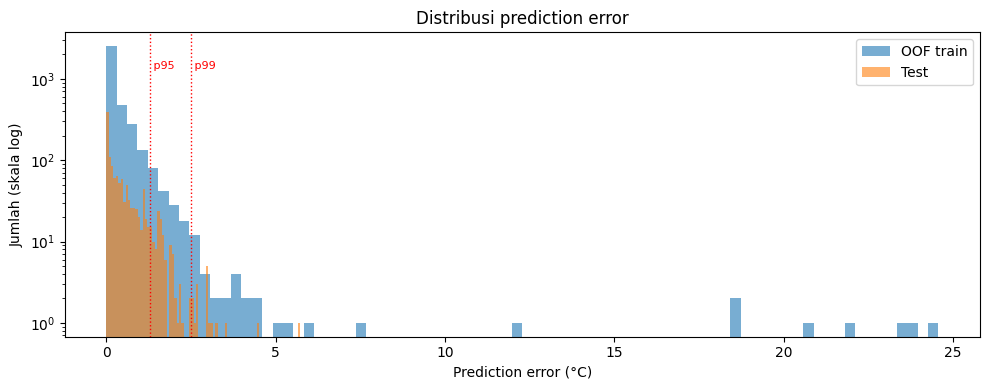

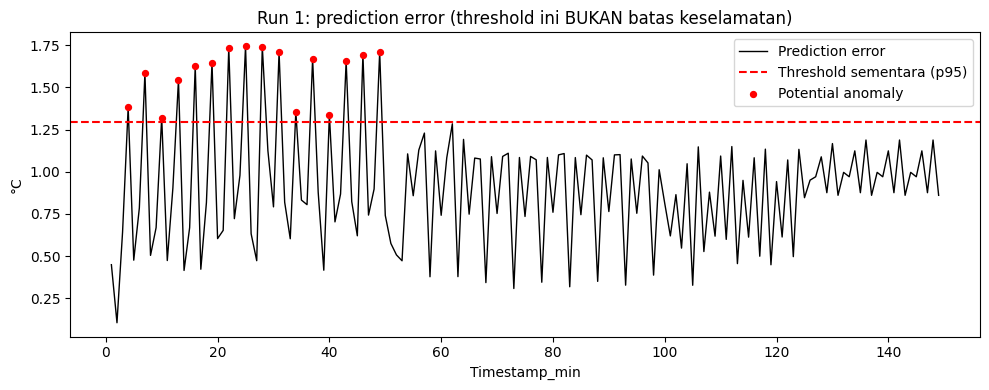

PosixPath('artifacts/images/09_error_dan_threshold_run_test.png')

In [ ]:
# Grafik 8: distribusi prediction error (skala log) + garis kandidat threshold
fig, ax = plt.subplots()
ax.hist(err_oof_train, bins=80, alpha=0.6, label='OOF train')
ax.hist(err_test, bins=80, alpha=0.6, label='Test')
for name, value in threshold_options_train.items():
    if name in ('p95', 'p99'):
        ax.axvline(value, color='r', ls=':', lw=1)
        ax.text(value, ax.get_ylim()[1] * 0.5, ' ' + name, color='r', fontsize=8)
ax.set_yscale('log'); ax.set_xlabel('Prediction error (°C)'); ax.set_ylabel('Jumlah (skala log)')
ax.set_title('Distribusi prediction error'); ax.legend()
save_fig('08_distribusi_prediction_error')

# Grafik 9: prediction error sepanjang waktu pada satu run test + threshold sementara
d = test_predictions[test_predictions[RUN_COL] == demo_run].sort_values(TIME_COL)
flag = d['Abs_error'] > demo_threshold
fig, ax = plt.subplots()
ax.plot(d[TIME_COL] + EXPECTED_STEP, d['Abs_error'], 'k-', lw=1, label='Prediction error')
ax.axhline(demo_threshold, color='r', ls='--', label='Threshold sementara (' + PROVISIONAL_THRESHOLD + ')')
ax.scatter((d[TIME_COL] + EXPECTED_STEP)[flag], d['Abs_error'][flag], c='r', s=18, zorder=3, label='Potential anomaly')
ax.set_title('Run ' + str(demo_run) + ': prediction error (threshold ini BUKAN batas keselamatan)')
ax.set_xlabel(TIME_COL); ax.set_ylabel('°C'); ax.legend()
save_fig('09_error_dan_threshold_run_test')

## 6. Export Artefak: Model Final + Metadata

Setelah evaluasi selesai, model dilatih ulang pada **semua run** dengan hyperparameter yang sama (lebih banyak run = lebih baik untuk dipakai aplikasi). Kandidat threshold dihitung ulang dari error out-of-fold seluruh run.
Metadata menyimpan semua yang dibutuhkan backend agar preprocessing sama persis: urutan fitur, rentang training, hyperparameter, versi library, dan kandidat threshold.

In [ ]:
# Model final dilatih pada seluruh sampel
final_model = RandomForestRegressor(**BEST_PARAMS, n_jobs=-1).fit(X, y)

# Kandidat threshold final dari error out-of-fold seluruh run (oof_all sudah dihitung di bagian 5a)
err_oof_all = np.abs(y.values - oof_all)
threshold_options_final = build_threshold_options(err_oof_all)

bundle = {
    'model': final_model,
    'model_type': 'RandomForestRegressor',
    'model_version': MODEL_VERSION,
    'trained_at': datetime.now().isoformat(timespec='seconds'),
    'target': 'Reactor_Temp_C(t+1)',
    'features_in_order': FEATURES,
    'hyperparameters': BEST_PARAMS,
    'preprocessing': {'scaling': 'none', 'missing_value': 'baris kosong dibuang (tanpa imputasi)',
                      'expected_time_step_min': EXPECTED_STEP},
    'train_ranges': {c: [float(X[c].min()), float(X[c].max())] for c in FEATURES},
    'n_train_samples': int(len(X)),
    'n_train_runs': int(n_runs),
    'evaluation_on_test_split': eval_table[['MAE_C', 'RMSE_C', 'R2']].to_dict(orient='index'),
    'cv_mae_mean_std_c': [float(cv_table['MAE_RF_C'].mean()), float(cv_table['MAE_RF_C'].std())],
    'anomaly': {
        'definition': '|Actual(t+1) - Predicted(t+1)|; threshold dari error out-of-fold seluruh run',
        'threshold_options_celsius': threshold_options_final,
        'provisional_threshold_key': PROVISIONAL_THRESHOLD,
        'status': 'SEMENTARA - belum diputuskan tim',
        'disclaimer': 'Threshold bukan batas keselamatan. Anomaly bukan defect dan bukan unsafe condition.'},
    'library_versions': {'python': platform.python_version(), 'scikit-learn': sklearn.__version__,
                         'pandas': pd.__version__, 'numpy': np.__version__},
}

# 1) Model + metadata dalam satu file joblib (dipakai backend)
model_path = MODEL_DIR / 'reactor_temp_model.joblib'
joblib.dump(bundle, model_path)
SAVED_FILES.append(model_path)

# 2) Metadata yang bisa dibaca manusia (tanpa objek model)
meta_path = MODEL_DIR / 'reactor_temp_model_metadata.json'
metadata = {k: v for k, v in bundle.items() if k != 'model'}
with open(meta_path, 'w', encoding='utf-8') as f:
    json.dump(to_jsonable(metadata), f, indent=2, ensure_ascii=False)
SAVED_FILES.append(meta_path)

print('Tersimpan:', model_path)
print('Tersimpan:', meta_path)
print('Kandidat threshold final (°C):', {k: round(v, 3) for k, v in threshold_options_final.items()})

Tersimpan: artifacts/model/reactor_temp_model.joblib
Tersimpan: artifacts/model/reactor_temp_model_metadata.json
Kandidat threshold final (°C): {'p90': 0.928, 'p95': 1.309, 'p99': 2.25, 'mean_plus_2std': 2.306, 'mean_plus_3std': 3.28}


### Uji muat ulang & contoh inference

Memastikan file `.joblib` bisa dimuat ulang dan menghasilkan prediksi identik. Fungsi `predict_next_temperature` juga memperlihatkan validasi input (kolom hilang, bukan angka, di luar rentang training) sesuai PRD 19, dan hanya memakai status *Normal pattern* / *Potential anomaly* / *Prediction error tidak tersedia*.

In [ ]:
# Uji M9/M10: muat ulang, urutan fitur sama, prediksi identik dengan model di memori
reloaded = joblib.load(model_path)
assert reloaded['features_in_order'] == FEATURES, 'Urutan fitur berbeda setelah dimuat ulang'
assert np.allclose(reloaded['model'].predict(X_test[FEATURES]), final_model.predict(X_test[FEATURES]))
print('Uji muat ulang OK: model identik dan urutan fitur sama.')

# Nama field API (draf PRD 16.1) -> nama kolom dataset
API_FIELDS = {'reactor_temp_c': TEMP_COL, 'jacket_flow_rate_l_min': 'Jacket_Flow_Rate_L_min',
              'pressure_atm': 'Pressure_atm', 'reactant_a_conc_mol_l': 'Reactant_A_Conc_mol_L',
              'product_b_conc_mol_l': 'Product_B_Conc_mol_L'}


def predict_next_temperature(payload, actual_next_temperature_c=None, threshold_key=None, bundle_path=model_path):
    # Prediksi suhu t+1 + status monitoring. Input salah -> pesan error, TANPA angka palsu.
    b = joblib.load(bundle_path)                       # di backend: cukup dimuat sekali saat startup
    errors, warns, values = [], [], {}

    for api_key, col in API_FIELDS.items():            # validasi kelengkapan, tipe, NaN/Inf
        raw_value = payload.get(api_key)
        if raw_value is None or raw_value == '':
            errors.append('Field wajib hilang: ' + api_key)
            continue
        try:
            v = float(raw_value)
        except (TypeError, ValueError):
            errors.append('Field bukan angka: ' + api_key)
            continue
        if math.isnan(v) or math.isinf(v):
            errors.append('Nilai tidak valid (NaN/Inf): ' + api_key)
            continue
        values[col] = v
    if errors:
        return {'ok': False, 'errors': errors}

    for col in b['features_in_order']:                 # di luar rentang training -> peringatan saja
        lo, hi = b['train_ranges'][col]
        if not (lo <= values[col] <= hi):
            warns.append(col + '=' + str(values[col]) + ' di luar rentang data training [' + str(round(lo, 4)) + ', ' +
                         str(round(hi, 4)) + ']; interpretasikan hasil dengan hati-hati.')

    x_new = pd.DataFrame([[values[c] for c in b['features_in_order']]], columns=b['features_in_order'])
    predicted = float(b['model'].predict(x_new)[0])

    key = threshold_key or b['anomaly']['provisional_threshold_key']
    threshold = b['anomaly']['threshold_options_celsius'][key]
    if actual_next_temperature_c is None:
        monitoring = {'status': 'Prediction error tidak tersedia', 'prediction_error_c': None}
    else:
        err = abs(float(actual_next_temperature_c) - predicted)
        monitoring = {'status': 'Potential anomaly' if err > threshold else 'Normal pattern',
                      'prediction_error_c': round(err, 4)}
    monitoring.update({'threshold_c': round(threshold, 4), 'threshold_key': key,
                       'note': 'Threshold bukan batas keselamatan. Anomaly bukan defect dan bukan unsafe condition.'})
    return {'ok': True, 'predicted_next_temperature_c': round(predicted, 3),
            'label': 'Hasil model ML, bukan hasil pengukuran',
            'model_version': b['model_version'], 'warnings': warns, 'monitoring': monitoring}


# Contoh dengan satu baris nyata dari data
row = model_df.iloc[len(model_df) // 2]
example = {k: float(row[col]) for k, col in API_FIELDS.items()}
print(predict_next_temperature(example))
print(predict_next_temperature(example, actual_next_temperature_c=float(row[TARGET_COL]))['monitoring']['status'])
print(predict_next_temperature({'reactor_temp_c': 85}))                      # contoh error: field hilang

Uji muat ulang OK: model identik dan urutan fitur sama.
{'ok': True, 'predicted_next_temperature_c': 85.073, 'label': 'Hasil model ML, bukan hasil pengukuran', 'model_version': 'rf-t1-v0.2', 'warnings': [], 'monitoring': {'status': 'Prediction error tidak tersedia', 'prediction_error_c': None, 'threshold_c': 1.3086, 'threshold_key': 'p95', 'note': 'Threshold bukan batas keselamatan. Anomaly bukan defect dan bukan unsafe condition.'}}
Normal pattern
{'ok': False, 'errors': ['Field wajib hilang: jacket_flow_rate_l_min', 'Field wajib hilang: pressure_atm', 'Field wajib hilang: reactant_a_conc_mol_l', 'Field wajib hilang: product_b_conc_mol_l']}


In [ ]:
readme_lines = [
    'ARTEFAK BATCH REACTOR - PREDIKSI TEMPERATUR t+1 + MONITORING ANOMALI',
    'Dibuat: ' + datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'Model : ' + MODEL_VERSION + ' (RandomForestRegressor)',
    '',
    'Catatan penting:',
    '- Threshold anomali bersifat SEMENTARA dan BUKAN batas keselamatan reaktor.',
    '- Anomaly (menyimpang dari pola model) bukan defect dan bukan unsafe condition.',
    '- Model dilatih pada data historis; tidak untuk mengendalikan reaktor nyata.',
    '',
    'Daftar file:',
]
for p in sorted(set(SAVED_FILES), key=lambda p: str(p)):
    readme_lines.append('  - ' + str(p.relative_to(OUTPUT_DIR)) + '  (' + str(round(p.stat().st_size / 1024, 1)) + ' KB)')

readme_path = OUTPUT_DIR / 'README.txt'
readme_path.write_text('\n'.join(readme_lines), encoding='utf-8')
SAVED_FILES.append(readme_path)

zip_path = shutil.make_archive('artifacts_batch_reactor', 'zip', root_dir=OUTPUT_DIR)
print('\n'.join(readme_lines))
print('\nZIP    :', zip_path)

# Di Google Colab: unduh ZIP otomatis. Di luar Colab: lewati.
try:
    from google.colab import files
    files.download(zip_path)
except ImportError:
    pass

ARTEFAK BATCH REACTOR - PREDIKSI TEMPERATUR t+1 + MONITORING ANOMALI
Dibuat: 2026-10-01 07:31:10
Model : rf-t1-v0.2 (RandomForestRegressor)

Catatan penting:
- Threshold anomali bersifat SEMENTARA dan BUKAN batas keselamatan reaktor.
- Anomaly (menyimpang dari pola model) bukan defect dan bukan unsafe condition.
- Model dilatih pada data historis; tidak untuk mengendalikan reaktor nyata.

Daftar file:
  - README.txt  (1.6 KB)
  - images/01_profil_suhu_per_run.png  (123.2 KB)
  - images/02_panjang_run.png  (31.2 KB)
  - images/03_aktual_vs_prediksi.png  (54.6 KB)
  - images/04_distribusi_residual.png  (27.4 KB)
  - images/05_mae_per_run_test.png  (23.5 KB)
  - images/06_deret_waktu_run_test.png  (184.5 KB)
  - images/07_feature_importance.png  (35.0 KB)
  - images/08_distribusi_prediction_error.png  (37.9 KB)
  - images/09_error_dan_threshold_run_test.png  (108.6 KB)
  - model/reactor_temp_model.joblib  (5053.1 KB)
  - model/reactor_temp_model_metadata.json  (2.0 KB)
  - tables/cv_fold_

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>